# 02 · Preprocesamiento y referencia clásica

En este cuaderno cubro el Paso 2. Tomo los NIfTI del Paso 1 y los dejo en la forma en que
la red los va a mirar, y después construyo la referencia clásica: una segmentación sin
ninguna red, con las herramientas del curso (umbral, morfología, componentes conexas),
medida con las métricas oficiales de autoPET. Ese número es mi piso. Si un modelo no lo
supera, algo está mal en el modelo, no en la idea.

Como en el cuaderno anterior, todo corre primero sobre fantomas que fabrico aquí mismo;
la última sección trabaja con los estudios reales que ya están procesados.

In [1]:
import sys, tempfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RAIZ = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src")); sys.path.insert(0, str(RAIZ / "tests"))
from petct.convert import convert_study
from petct.preprocess import preprocess_study, load_study, sample_patch, window_ct, scale_suv, body_mask
from petct.classical import classical_segmentation, heuristic_organ_masks, threshold_suv, clean_mask
from petct.metrics import evaluate_study
import synthetic
ML = 0.027   # mL por vóxel a 3 mm: 0.3 cm x 0.3 cm x 0.3 cm
print("raíz:", RAIZ)

raíz: /Users/sebas/Proyectos/proyecto_PETCT_BME423


## 1. Ventaneo del CT y tope del SUV

Son las dos operaciones puntuales del paso. El ventaneo es lo mismo que hace la consola
cuando elijo "ventana de tejido blando": todo lo que está bajo −200 HU se vuelve 0, todo
lo que pasa de 300 HU se vuelve 1, y el medio queda lineal. La red no necesita distinguir
hueso cortical de hueso esponjoso, pero sí grasa de músculo de agua.

El SUV lo divido por 30 y lo recorto a 1. Sin ese tope, la vejiga (que llega a SUV 50 o
más) me obligaría a comprimir todo el resto del cuerpo en el primer 5 % de la escala.

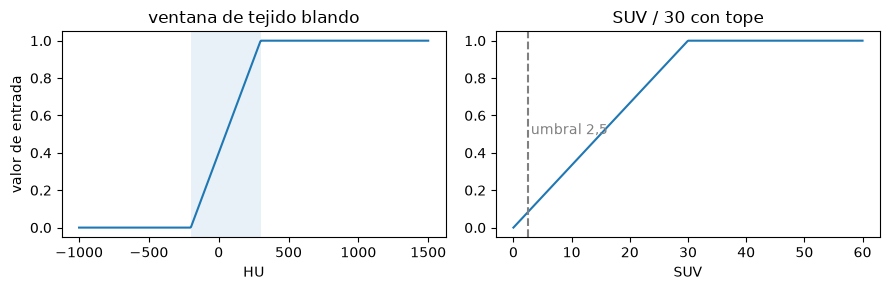

In [2]:
hu = np.linspace(-1000, 1500, 500)
suv = np.linspace(0, 60, 500)
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(hu, window_ct(hu)); ax[0].set_xlabel("HU"); ax[0].set_ylabel("valor de entrada"); ax[0].set_title("ventana de tejido blando")
ax[0].axvspan(-200, 300, alpha=.1)
ax[1].plot(suv, scale_suv(suv)); ax[1].set_xlabel("SUV"); ax[1].set_title("SUV / 30 con tope")
ax[1].axvline(2.5, ls="--", c="gray"); ax[1].text(3, .5, "umbral 2,5", color="gray")
plt.tight_layout(); plt.show()

## 2. El fantoma del Paso 1 pasa por el preprocesamiento

`preprocess_study` remuestrea a 3 mm isotrópicos (el PET del fantoma tenía vóxeles de
4 × 4 × 2 mm), calcula la máscara del cuerpo desde el CT, recorta a la caja que contiene al
paciente y guarda un `.npz` con `suv`, `ct`, `seg` y `body` alineados. Ese archivo es lo
que leerán los parches y los modelos: cualquiera de los 250 estudios se abre en
milisegundos.

In [3]:
root = Path(tempfile.mkdtemp(prefix="p2_"))
synthetic.make_phantom(root)
convert_study(root, root / "nifti")
info = preprocess_study(root / "nifti", root / "proc" / "fantoma.npz")
vol = load_study(root / "proc" / "fantoma.npz")
print("forma tras remuestrear y recortar (z, y, x):", vol["suv"].shape)
print(f"vóxeles de lesión: {info['lesion_voxels']}  ≈ {info['lesion_voxels']*ML:.2f} mL (esfera de 9 mm: 3.05 mL)")
print(f"fracción del volumen que es cuerpo: {vol['body'].mean():.2f}")

forma tras remuestrear y recortar (z, y, x): (13, 32, 38)
vóxeles de lesión: 116  ≈ 3.13 mL (esfera de 9 mm: 3.05 mL)
fracción del volumen que es cuerpo: 0.57


## 3. Parches sesgados a lesiones

La red no ve el cuerpo entero: ve cubos de 96³ vóxeles (29 cm de lado a 3 mm). Si eligiera
los cubos al azar, la mayoría no tendría ni un vóxel de lesión (las lesiones son menos del
1 % del cuerpo) y la red aprendería que la respuesta correcta es siempre "nada". Por eso
centro el 70 % de los parches en un vóxel de lesión y el 30 % en un vóxel cualquiera del
cuerpo. En el fantoma uso cubos chicos para poder dibujarlos.

de 200 parches con p_lesion = 0.7, 173 contienen lesión


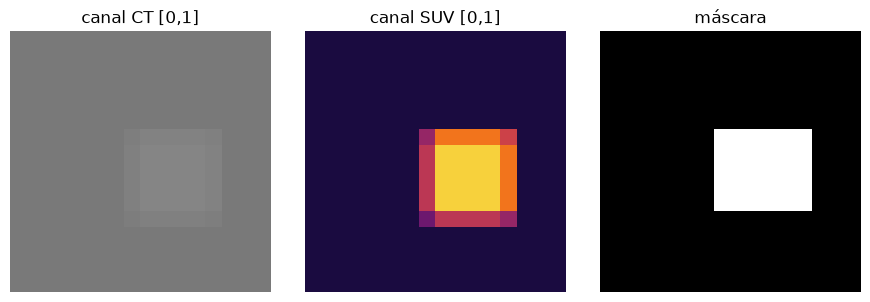

In [4]:
rng = np.random.default_rng(423)
con = sum(sample_patch(vol, (16, 16, 16), p_lesion=0.7, rng=rng)["with_lesion"] for _ in range(200))
print(f"de 200 parches con p_lesion = 0.7, {con} contienen lesión")
p = sample_patch(vol, (16, 16, 16), p_lesion=1.0, rng=rng)
z = p["seg"].sum(axis=(1, 2)).argmax()
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].imshow(p["ct"][z], cmap="gray", vmin=0, vmax=1); ax[0].set_title("canal CT [0,1]")
ax[1].imshow(p["suv"][z], cmap="inferno", vmin=0, vmax=0.3); ax[1].set_title("canal SUV [0,1]")
ax[2].imshow(p["seg"][z], cmap="gray"); ax[2].set_title("máscara")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 4. La referencia clásica, con un fantoma más parecido a un paciente

Para mostrar lo que el umbral hace mal necesito un cuerpo con órganos calientes. Este
fantoma lo armo directo en NumPy, ya a 3 mm: un cilindro de 60 cm de alto con fondo SUV 1,
un "encéfalo" de SUV 7 arriba, una "vejiga" de SUV 25 abajo, un "hígado" de SUV 2,2 (justo
bajo el umbral) y dos lesiones, una de SUV 6 y otra de SUV 4.

La receta clásica tiene cuatro pasos y los miro por separado: umbral, apertura
morfológica, tamaño mínimo y exclusión anatómica. Los tres primeros son lo que un físico
médico habría hecho hace veinte años. El cuarto es el que decide el resultado y depende de
tener máscaras de órganos; mientras no las tenga, dos reglas provisionales buscan el
encéfalo (la componente caliente grande más alta) y la vejiga (la componente muy intensa
más baja). Un detalle que importa: en este fantoma la cabeza está en el índice 0 del
arreglo; en los NIfTI de autoPET está al final, porque en DICOM la coordenada z crece
hacia la cabeza. Por eso las funciones reciben `head_at_end`.

In [5]:
def paciente_sintetico():
    Z, Y, X = 200, 100, 100                     # 60 x 30 x 30 cm a 3 mm
    zz, yy, xx = np.mgrid[:Z, :Y, :X]
    body = ((yy - 50) / 45) ** 2 + ((xx - 50) / 45) ** 2 <= 1
    suv = np.where(body, 1.0, 0.0)
    def esfera(c, r): return (zz - c[0]) ** 2 + (yy - c[1]) ** 2 + (xx - c[2]) ** 2 <= r ** 2
    suv[esfera((15, 50, 50), 20)] = 7.0          # encéfalo: ~900 mL
    suv[esfera((170, 50, 50), 10)] = 25.0        # vejiga: ~110 mL
    higado = esfera((90, 45, 35), 18); suv[higado] = 2.2
    seg = np.zeros_like(body)
    for c, r, s in (((70, 50, 65), 5, 6.0), ((120, 40, 50), 3, 4.0)):
        m = esfera(c, r); suv[m] = s; seg |= m
    return suv, body, seg

suv_p, body_p, seg_p = paciente_sintetico()
print(f"lesiones anotadas: {seg_p.sum()*ML:.1f} mL")

etapas = {}
etapas["1 umbral 2,5"] = threshold_suv(suv_p) & body_p
etapas["2+3 apertura y tamaño"] = clean_mask(etapas["1 umbral 2,5"], 1, 0.5, ML)
etapas["4 exclusión anatómica"] = classical_segmentation(suv_p, body_p, ML, head_at_end=False)
for nombre, m in etapas.items():
    r = evaluate_study(m, seg_p, suv_p, ML)
    print(f"{nombre:26s} Dice={r['dice']:.3f}  FPV={r['fpv_ml']:7.1f} mL  FNV={r['fnv_ml']:.1f} mL  MTV pred={r['mtv_pred_ml']:.1f} mL")

lesiones anotadas: 17.2 mL


1 umbral 2,5               Dice=0.034  FPV=  983.3 mL  FNV=0.0 mL  MTV pred=1000.5 mL
2+3 apertura y tamaño      Dice=0.032  FPV=  982.6 mL  FNV=0.0 mL  MTV pred=998.9 mL
4 exclusión anatómica      Dice=0.971  FPV=    0.0 mL  FNV=0.0 mL  MTV pred=16.3 mL


Lo leo como radiólogo: el umbral solo marca el encéfalo y la vejiga como tumor y el MTV
se dispara a más de mil mililitros. La apertura y el tamaño mínimo no cambian nada,
porque esos órganos son grandes y compactos. Solo la exclusión anatómica baja el FPV a
cero. Esa es la hipótesis del proyecto entero, dicha con reglas fijas: la anatomía es lo
que separa captación fisiológica de patológica. Con los modelos B y C busco que la red
aprenda esa regla sola a partir del CT.

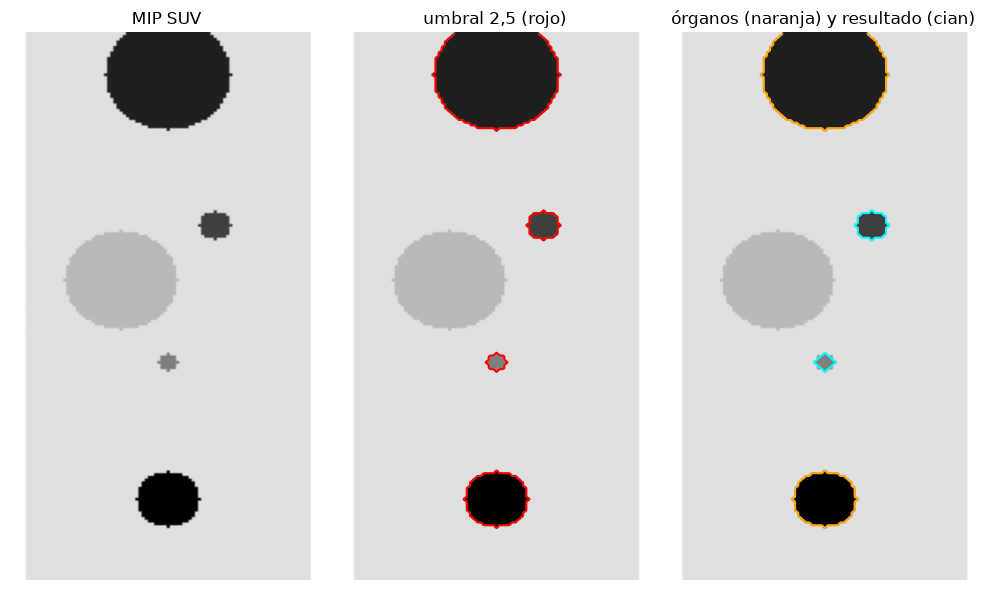

In [6]:
organos = heuristic_organ_masks(suv_p, body_p, ML, head_at_end=False)
mip = suv_p.max(axis=1)
fig, ax = plt.subplots(1, 3, figsize=(10, 6))
ax[0].imshow(mip, cmap="gray_r", vmin=0, vmax=8, aspect="auto"); ax[0].set_title("MIP SUV")
ax[1].imshow(mip, cmap="gray_r", vmin=0, vmax=8, aspect="auto"); ax[1].contour(etapas["1 umbral 2,5"].max(axis=1), levels=[.5], colors="red"); ax[1].set_title("umbral 2,5 (rojo)")
ax[2].imshow(mip, cmap="gray_r", vmin=0, vmax=8, aspect="auto")
for nombre, m in organos.items():
    ax[2].contour(m.max(axis=1), levels=[.5], colors="orange")
ax[2].contour(etapas["4 exclusión anatómica"].max(axis=1), levels=[.5], colors="cyan"); ax[2].set_title("órganos (naranja) y resultado (cian)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 5. Con estudios reales

Aquí uso los `.npz` de `data/processed` (salida de `scripts/04`): corro la referencia
clásica en todos y muestro la tabla. Con pacientes de verdad espero Dice bajo y FPV alto,
incluso con la exclusión heurística: el corazón, los riñones y el intestino no están
cubiertos por las dos reglas, y las lesiones de SUV 3 quedan pegadas al hígado. Ese es el
punto: documentar cuánto falla la receta clásica y en qué órganos, para tener contra qué
comparar los modelos.

In [7]:
import pandas as pd
proc = sorted((RAIZ / "data/processed").glob("*.npz"))
if proc:
    filas = []
    for f in proc:
        v = load_study(f); suv_r = v["suv"] * v["suv_top"]
        pred = classical_segmentation(suv_r, v["body"], ML, head_at_end=v["head_at_end"])
        r = evaluate_study(pred, v["seg"], suv_r, ML); r["estudio"] = f.stem[:20]; filas.append(r)
    df = pd.DataFrame(filas).set_index("estudio")
    display(df.round(2))
    print("promedio Dice / FPV / FNV:", df[["dice", "fpv_ml", "fnv_ml"]].mean().round(2).to_dict())
else:
    print("Todavía no hay estudios procesados (se generan con scripts/04_preprocesar.py).")

,dice,fpv_ml,fnv_ml,mtv_pred_ml,mtv_gt_ml,suvmax_pred,suvmax_gt
estudio,,,,,,,
PETCT_0117d7f11f__1.,0.51,20.84,55.76,102.90,183.71,14.23,14.23
PETCT_01682f60c3__1.,0.19,476.31,1.11,551.04,145.10,25.87,25.87
PETCT_04606080a0__1.,0.38,202.18,0.00,284.23,117.53,18.16,18.16
PETCT_05d5a79faf__1.,0.00,769.23,0.00,769.23,0.00,15.04,0.00
PETCT_06a46414eb__1.,0.02,421.79,0.00,427.90,5.78,23.86,13.59
...,...,...,...,...,...,...,...
PETCT_f65602d938__1.,0.09,387.75,14.23,1216.67,73.39,30.00,30.00
PETCT_f9c4d4f9ab__1.,0.17,636.66,0.00,2430.13,234.44,30.00,12.52
PETCT_fb014a1ea0__1.,0.07,192.51,0.00,219.54,7.86,9.46,7.98


promedio Dice / FPV / FNV: {'dice': 0.16, 'fpv_ml': 726.12, 'fnv_ml': 19.67}


## Lo que anoto en la bitácora

La forma típica de los volúmenes a 3 mm (para dimensionar memoria), cuántos estudios
fallaron en el preprocesamiento, y la tabla de la referencia clásica con su promedio de
Dice, FPV y FNV. Ese promedio es el primer número del informe.